In [1]:
import pandas as pd
df = pd.read_csv("../data/proccesed/cleaned_data.csv")



In [2]:
import pandas as pd
import matplotlib.pyplot as plt


df['timestamp'] = pd.to_datetime(df['timestamp'])


df['date'] = df['timestamp'].dt.date

attendance = df[df['event_type'] == 'Check-In'].copy()

attendance = attendance.dropna(subset=['department'])

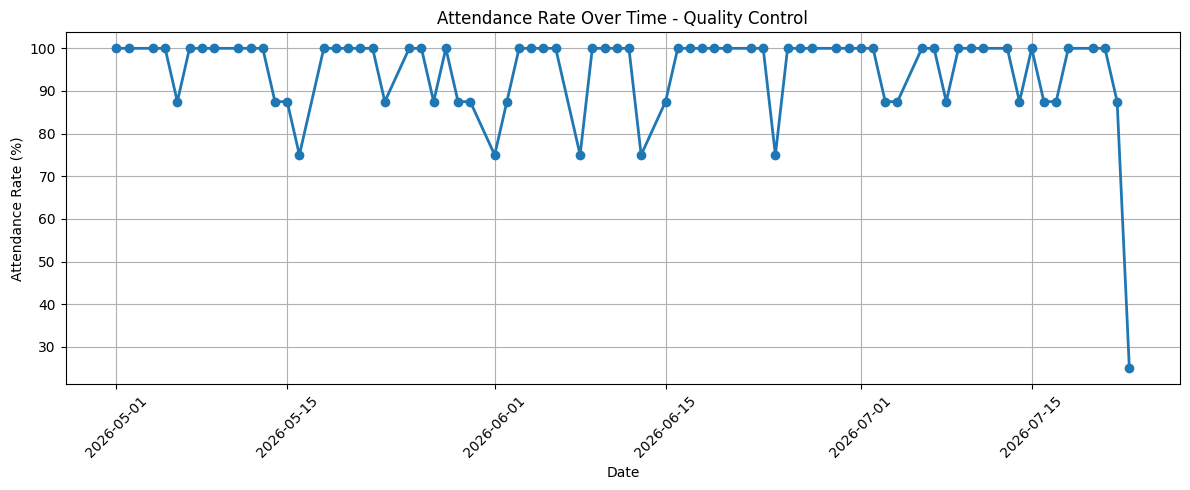

In [3]:
sample_department = "Quality Control"

dept = attendance[attendance['department'] == sample_department]

daily_present = dept.groupby('date')['employee_id'].nunique()

total_employees = dept['employee_id'].nunique()


attendance_rate = (daily_present / total_employees) * 100

plt.figure(figsize=(12,5))

plt.plot(attendance_rate.index,
         attendance_rate.values,
         marker='o',
         linewidth=2)

plt.title(f"Attendance Rate Over Time - {sample_department}")
plt.xlabel("Date")
plt.ylabel("Attendance Rate (%)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

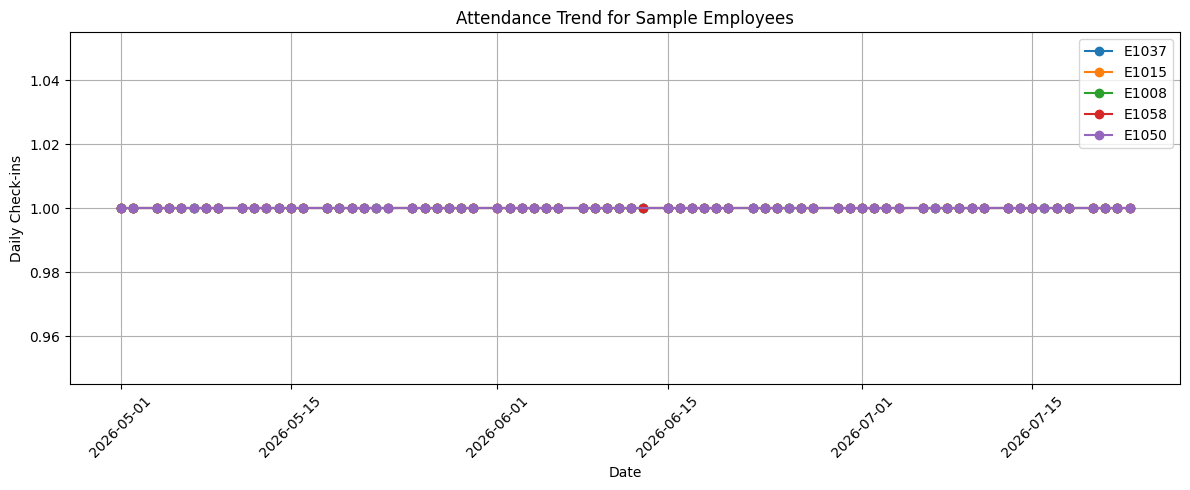

In [4]:
sample_employees = attendance['employee_id'].unique()[:5]

plt.figure(figsize=(12,5))

for emp in sample_employees:

    emp_data = attendance[attendance['employee_id'] == emp]

    daily = emp_data.groupby('date').size()

    plt.plot(daily.index,
             daily.values,
             marker='o',
             label=emp)

plt.title("Attendance Trend for Sample Employees")
plt.xlabel("Date")
plt.ylabel("Daily Check-ins")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [5]:
print("Average Attendance Rate:",
      round(attendance_rate.mean(),2), "%")

print("Highest Attendance:",
      round(attendance_rate.max(),2), "%")

print("Lowest Attendance:",
      round(attendance_rate.min(),2), "%")

Average Attendance Rate: 94.44 %
Highest Attendance: 100.0 %
Lowest Attendance: 25.0 %


In [6]:
working_days = attendance['date'].nunique()

employee_days = attendance.groupby('employee_id')['date'].nunique()

summary = pd.DataFrame()

summary['Days_Present'] = employee_days

summary['Attendance_Rate'] = (
    summary['Days_Present'] / working_days
) * 100

summary['Days_Absent'] = (
    working_days - summary['Days_Present']
)

summary['Chronic_Absentee'] = summary['Attendance_Rate'] < 80

summary = summary.sort_values(
    by='Attendance_Rate'
)

print(summary.head(20))

             Days_Present  Attendance_Rate  Days_Absent  Chronic_Absentee
employee_id                                                              
E1044                  65        77.380952           19              True
E1028                  66        78.571429           18              True
E1053                  66        78.571429           18              True
E1060                  66        78.571429           18              True
E1030                  67        79.761905           17              True
E1016                  67        79.761905           17              True
E1024                  67        79.761905           17              True
E1031                  67        79.761905           17              True
E1058                  67        79.761905           17              True
E1039                  67        79.761905           17              True
E1057                  67        79.761905           17              True
E1056                  67        79.76

In [7]:
chronic = summary[
    summary['Chronic_Absentee'] == True
]

print(chronic)

             Days_Present  Attendance_Rate  Days_Absent  Chronic_Absentee
employee_id                                                              
E1044                  65        77.380952           19              True
E1028                  66        78.571429           18              True
E1053                  66        78.571429           18              True
E1060                  66        78.571429           18              True
E1030                  67        79.761905           17              True
E1016                  67        79.761905           17              True
E1024                  67        79.761905           17              True
E1031                  67        79.761905           17              True
E1058                  67        79.761905           17              True
E1039                  67        79.761905           17              True
E1057                  67        79.761905           17              True
E1056                  67        79.76

In [8]:
summary.sort_values(
    by='Attendance_Rate'
).head(10)

,Days_Present,Attendance_Rate,Days_Absent,Chronic_Absentee
employee_id,,,,
E1044,65,77.380952,19,True
E1028,66,78.571429,18,True
E1053,66,78.571429,18,True
E1060,66,78.571429,18,True
E1030,67,79.761905,17,True
E1016,67,79.761905,17,True
E1024,67,79.761905,17,True
E1031,67,79.761905,17,True
E1058,67,79.761905,17,True


/

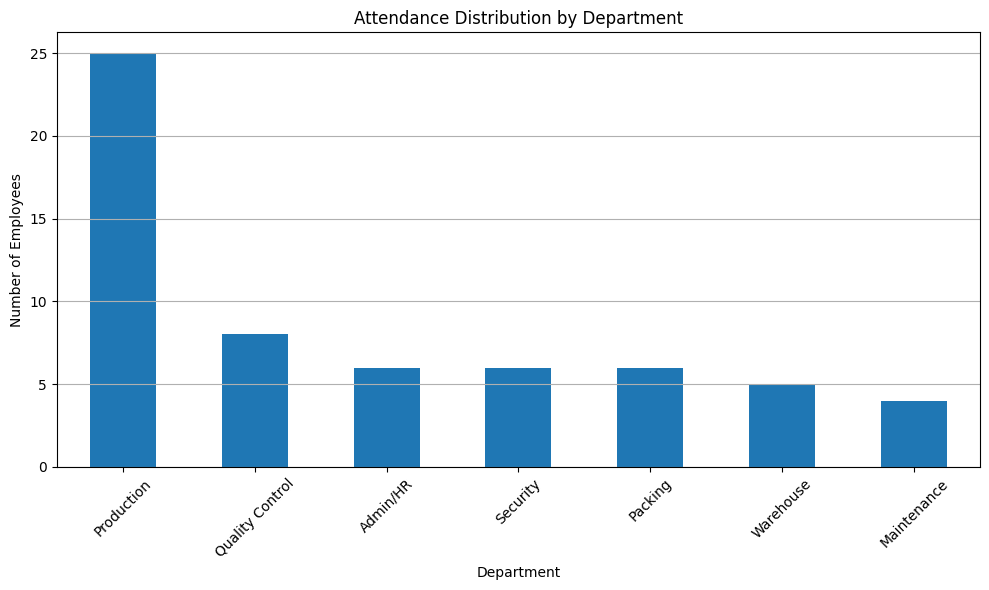

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/proccesed/cleaned_data.csv')

dept_attendance = attendance.groupby('department')['employee_id'].nunique().sort_values(ascending=False)

plt.figure(figsize=(10,6))
dept_attendance.plot(kind='bar')

plt.title("Attendance Distribution by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.tight_layout()
plt.show()

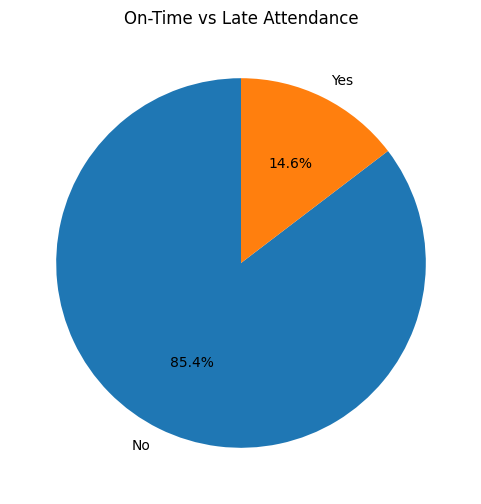

In [10]:
late_counts = attendance['is_late'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    late_counts,
    labels=late_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("On-Time vs Late Attendance")

plt.show()

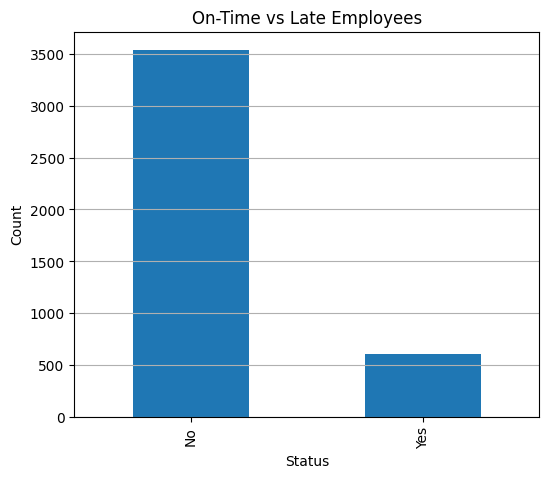

In [11]:
late_counts = attendance['is_late'].value_counts()

plt.figure(figsize=(6,5))

late_counts.plot(kind='bar')

plt.title("On-Time vs Late Employees")
plt.xlabel("Status")
plt.ylabel("Count")

plt.grid(axis='y')

plt.show()

In [12]:
total_sessions = len(df)

successful_checkins = (df['event_type'] == 'Check-In').sum()

late_arrivals = (df['is_late'] == 'Yes').sum()

early_exit = (df['is_early_exit'] == 'Yes').sum()

unique_employees = df['employee_id'].nunique()

print("="*40)
print("SESSION SUMMARY")
print("="*40)

print(f"Total Sessions          : {total_sessions}")
print(f"Unique Employees        : {unique_employees}")
print(f"Successful Check-ins    : {successful_checkins}")
print(f"Late Arrivals           : {late_arrivals}")
print(f"Early Exits             : {early_exit}")

print("="*40)

SESSION SUMMARY
Total Sessions          : 10000
Unique Employees        : 83
Successful Check-ins    : 4148
Late Arrivals           : 607
Early Exits             : 352


In [13]:
print(df['device_health_score'].describe())

count    10000.000000
mean        85.543790
std          5.891898
min         70.100000
25%         80.900000
50%         85.600000
75%         90.500000
max         99.300000
Name: device_health_score, dtype: float64


In [14]:
print(df['authentication_time_ms'].describe())

count    10000.000000
mean       375.818580
std        105.063912
min        150.000000
25%        313.475000
50%        354.850000
75%        406.400000
max       1354.800000
Name: authentication_time_ms, dtype: float64


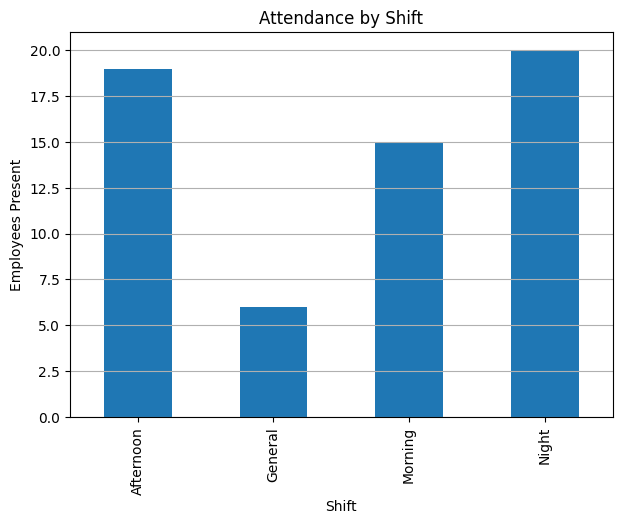

In [15]:
shift_attendance = attendance.groupby('shift')['employee_id'].nunique()

plt.figure(figsize=(7,5))

shift_attendance.plot(kind='bar')

plt.title("Attendance by Shift")
plt.xlabel("Shift")
plt.ylabel("Employees Present")

plt.grid(axis='y')

plt.show()

/

In [17]:
import pandas as pd

total_working_days = attendance['date'].nunique()

ranking = attendance.groupby(['employee_id', 'department']).agg(
    Days_Present=('date', 'nunique'),
    Late_Count=('is_late', lambda x: (x == 'Yes').sum())
).reset_index()

ranking['Attendance_Rate (%)'] = (
    ranking['Days_Present'] / total_working_days * 100
).round(2)

ranking['Days_Absent'] = total_working_days - ranking['Days_Present']

ranking['Rank'] = (
    ranking['Attendance_Rate (%)']
    .rank(method='dense', ascending=False)
    .astype(int)
)

threshold = 80

ranking['Warning'] = ranking['Attendance_Rate (%)'].apply(
    lambda x: " Below Threshold" if x < threshold else " Good"
)

ranking = ranking.sort_values('Rank')

print(ranking.head(20))

   employee_id       department  Days_Present  Late_Count  \
51       E1052         Security            76          15   
10       E1011         Security            75          11   
12       E1013         Security            74          10   
41       E1042         Security            73          13   
18       E1019         Security            72          12   
47       E1048         Security            72          10   
24       E1025       Production            71          15   
1        E1002        Warehouse            71          12   
48       E1049       Production            71          14   
5        E1006       Production            71           6   
49       E1050  Quality Control            71          11   
50       E1051      Maintenance            71          14   
17       E1018       Production            70          13   
20       E1021       Production            70          11   
4        E1005       Production            70          11   
0        E1001       Pro

In [18]:
ranking[['Rank',
         'employee_id',
         'department',
         'Days_Present',
         'Days_Absent',
         'Attendance_Rate (%)',
         'Late_Count',
         'Warning']]

,Rank,employee_id,department,Days_Present,Days_Absent,Attendance_Rate (%),Late_Count,Warning
51,1,E1052,Security,76,8,90.48,15,Good
10,2,E1011,Security,75,9,89.29,11,Good
12,3,E1013,Security,74,10,88.10,10,Good
41,4,E1042,Security,73,11,86.90,13,Good
18,5,E1019,Security,72,12,85.71,12,Good
47,5,E1048,Security,72,12,85.71,10,Good
24,6,E1025,Production,71,13,84.52,15,Good
1,6,E1002,Warehouse,71,13,84.52,12,Good
48,6,E1049,Production,71,13,84.52,14,Good
5,6,E1006,Production,71,13,84.52,6,Good
